In [1]:
!pip install langchain langgraph cassio

In [2]:
!pip install langchain-community

In [3]:
!pip install tiktoken langchain-groq langchainhub langchain_huggingface

In [4]:
import cassio
from google.colab import userdata
# provide connection of the AstraDB
ASTRA_DB_APPLICATION_TOKEN = userdata.get("ASTRADB_TOKEN")
ASTRA_DB_ID = userdata.get('ASTRADB_ID')
cassio.init(token=ASTRA_DB_APPLICATION_TOKEN, database_id=ASTRA_DB_ID)

In [5]:
# build index
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader

# Docs to index
urls = [
    "https://www.ruangguru.com/",
    "https://www.ruangguru.com/program",
    "https://www.ruangguru.com/program/deep-learning",
    "https://www.ruangguru.com/promo",
    "https://www.ruangguru.com/event",
    "https://www.ruangguru.com/event/clash-of-champions",
    "https://www.ruangguru.com/about-us",
    "https://www.ruangguru.com/utbk-snbt",
    "https://www.ruangguru.com/ruangbelajar",
    "https://www.ruangguru.com/testimoni"
]

# load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list=[item for sublist in docs for item in sublist]
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,
    chunk_overlap=0)
docs_split = text_splitter.split_documents(docs_list)

In [6]:
print(docs_list)

[Document(metadata={'source': 'https://www.ruangguru.com/', 'title': 'Aplikasi Bimbel Online Interaktif Terbaik #1 Indonesia | Ruangguru', 'description': 'Platform bimbingan belajar (bimbel) online terbesar di Indonesia untuk jenjang SD, SMP, SMA/SMK. Download & langganan Ruangguru mulai dari sekarang!', 'language': 'id'}, page_content='\n\n\n\n\n\n\n\nAplikasi Bimbel Online Interaktif Terbaik #1 Indonesia | Ruangguru\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nProduk\n\n\n\n\n\n\n\n\nBelajar seru dengan video dan latihan soal, anti remed!\n\n\n\n\n\n\n\n\nBimbel Tatap Muka & Live Interaktif bersama STAR Master Teacher\n\n\n\n\n\n\n\n\nKursus matematika dan logika untuk anak 5-14 tahun dengan kurikulum Singapura\n\n\n\n\n\n\n\n\nKursus hitung cepat aritmatika dengan sempoa untuk anak 4-12 tahun\n\n\n\n\n\n\n\n\nKursus latihan daya ingat, fokus, dan konsentrasi un

In [7]:
docs_split

[Document(metadata={'source': 'https://www.ruangguru.com/', 'title': 'Aplikasi Bimbel Online Interaktif Terbaik #1 Indonesia | Ruangguru', 'description': 'Platform bimbingan belajar (bimbel) online terbesar di Indonesia untuk jenjang SD, SMP, SMA/SMK. Download & langganan Ruangguru mulai dari sekarang!', 'language': 'id'}, page_content='Aplikasi Bimbel Online Interaktif Terbaik #1 Indonesia | Ruangguru\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nProduk\n\n\n\n\n\n\n\n\nBelajar seru dengan video dan latihan soal, anti remed!\n\n\n\n\n\n\n\n\nBimbel Tatap Muka & Live Interaktif bersama STAR Master Teacher\n\n\n\n\n\n\n\n\nKursus matematika dan logika untuk anak 5-14 tahun dengan kurikulum Singapura\n\n\n\n\n\n\n\n\nKursus hitung cepat aritmatika dengan sempoa untuk anak 4-12 tahun\n\n\n\n\n\n\n\n\nKursus latihan daya ingat, fokus, dan konsentrasi untuk mendukung pr

In [8]:
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from google.colab import userdata
import os
HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN
model_name = "BAAI/bge-small-en"
model_kwargs = {"device": "cpu"}
encode_kwargs = {"normalize_embeddings": True}
embeddings = HuggingFaceBgeEmbeddings(
    model_name=model_name, model_kwargs=model_kwargs, encode_kwargs=encode_kwargs
)

/tmp/ipython-input-3648436642.py:9: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceBgeEmbeddings(


In [9]:
from langchain_community.vectorstores import Cassandra
astra_vector_store = Cassandra(embedding=embeddings,
                               table_name="qna",
                               session=None,
                               keyspace=None)

In [10]:
from langchain_classic.indexes.vectorstore import VectorStoreIndexWrapper
astra_vector_store.add_documents(docs_split)
print("Inserted %i headlines" % len(docs_split))
astra_vector_index = VectorStoreIndexWrapper(vectorstore=astra_vector_store)

Inserted 128 headlines


In [11]:
retriever = astra_vector_store.as_retriever()
retriever.invoke("apa saja program di ruangguru")

[Document(id='a905d4c7bacf400ba14aa77d999466c7', metadata={'description': 'Pilih bimbel intensif UTBK-SNBT 2026 hanya di Ruangguru. Langganan sekarang dan saatnya wujudkan impian kuliah di universitas favorit.', 'language': 'id', 'source': 'https://www.ruangguru.com/utbk-snbt', 'title': 'Siap UTBK-SNBT 2026 & Lolos di Kampus Impian bersama Ruangguru'}, page_content='Hasil UTBK-SNBT 2026 akan diumumkan pada 25 Mei 2026.\n\n\n\nLihat Selengkapnya\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nRUANGGURU HQ\nGedung Sinarmas MSIG Tower Lt. 33. Jl. Jenderal Sudirman Kav. 21, Karet Kuningan, Setiabudi, Jakarta Selatan,\xa0Jakarta\xa012920\n\n\nCoba GRATIS Aplikasi Ruangguru\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nProduk Ruangguru\n\n\nRoboguru\n\n\nRoboguru Plus\n\n\nDafa dan Lulu\n\n\nRuangguru for Kids\n\n\nRuangguru for Business\n\n\nRuanguji\n\n\nRuangbaca\n\n\nRuangkelas\n\n\nRuangbelajar\n\n\nRuangpengajar\n\n\nRuangguru Privat\n\n\nRuangpeduli\n\n\nAiris\n\n\n\n\nProduk Lainnya\n\

In [12]:
!pip install -U ddgs

In [13]:
from langchain_community.tools import DuckDuckGoSearchRun
internet_search = DuckDuckGoSearchRun(name="Search")

In [14]:
## Langgraph application
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

In [15]:
# Data model
class RouteQuery(BaseModel):
  """Route a user query to the most relevant datasource"""

  datasource: Literal["vectorstore", "internet_search"] = Field(
      ...,
      description="Given a user question choose to route it to internet_search or a vectorestore"
  )

In [16]:
from langchain_groq import ChatGroq
groq_api_key = userdata.get('GROQ_API_KEY')
llm = ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7e28fe4fa210>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7e28fdfd3e00>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [17]:
structured_llm_router= llm.with_structured_output(RouteQuery)

In [18]:
# Prompt
system = """
You are an expert at routing user questions to a vectorstore or internet_search.

ROUTING LOGIC:
1. Use **vectorstore** for questions SPECIFICALLY about:
   - Ruangguru programs (Brain Academy, English Academy, etc.)
   - Promos, discounts, or prices listed in Ruangguru.
   - Ruangguru events (Clash of Champions, webinars).

2. Use **internet_search** for questions about:
   - **Exam Schedules** (Jadwal Ujian, SNBT, UTBK, Ujian Nasional, CPNS, Kedinasan).
   - Real-time university news or government announcements.
   - General knowledge not related to Ruangguru products.
   - Questions about "Major" or "Universities".

If you are unsure, prefer internet_search to get the latest information."""

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router = route_prompt | structured_llm_router

In [19]:
from langchain_core.documents import Document
## AI Agents application using langgraph
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
  """
  Represents the state of our graph.

  Attributes:
    question: question
    generation: LLM generation
    documents: list of documents
  """

  question: str
  generation: str
  documents: List[Document]

In [20]:
def retrieve(state):
  """
  Retrieve documents

  Args:
    state (dict): The current graph state

  returns:
    state (dict): New key added to state, documents, that contains retrieved documents
  """
  print("---RETRIEVER---")
  question = state['question']

  documents = retriever.invoke(question)
  return {"documents": documents, "question": question}

In [21]:
def internet_search_node(state):
  """
  internet search based on the re-phrased question

  Args:
      state (dict): The current graph state

  Return:
      state (dict): Updates documents key with appended internet search result

  """

  print("---internet search---")
  question = state['question']
  print(question)


  documents = internet_search.invoke(question)
  internet_seacrh_result = Document(page_content=documents)
  return {"documents": [internet_seacrh_result], "question": question}

In [22]:
def route_question(state):
  """
  Route question to vectorestore or internet search

  Args:
      state (dict): The current graph state

  Return:
      str: Next node to call
  """
  print("---ROUTE QUESTION---")
  question = state['question']
  print(question)
  source = question_router.invoke({"question": question})
  if source.datasource == "internet_search":
    print("---ROUTE QUESTION TO INTERNET SEARCH---")
    return "internet_search"
  elif source.datasource == "vectorstore":
    print("---ROUTE QUESTION TO RAG---")
    return "retrieve"

In [23]:
def generate(state):
    print("---GENERATING ANSWER---")
    question = state["question"]
    documents = state["documents"]
    context = "\n\n".join([doc.page_content for doc in documents])

    prompt = f"""Anda adalah seorang **Senior Customer Support Specialist** yang profesional, hangat, dan sangat membantu di **Ruangguru**.
    Tugas Anda adalah menjawab pertanyaan pengguna berdasarkan informasi yang diberikan di bawah ini.

    KONTEKS INFORMASI:
    ---------------------
    {context}
    ---------------------

    PERTANYAAN PENGGUNA:
    {question}

    PANDUAN MENJAWAB:
    1. Nada Bicara: Gunakan bahasa Indonesia yang sopan, ramah, dan profesional. Tunjukkan empati dan antusiasme.
    2. Akurasi: Jawab HANYA berdasarkan "KONTEKS INFORMASI" di atas. Jangan mengarang informasi yang tidak ada.
    3. Struktur:
      - Mulai dengan sapaan ramah (Contoh: "Halo! Terima kasih sudah bertanya...").
      - Jawab inti pertanyaan dengan jelas.
      - Gunakan **bullet points** jika menjelaskan daftar (seperti jadwal, fitur, atau harga) agar mudah dibaca.
      - Jika relevan, tambahkan kalimat **persuasif** yang menonjolkan keunggulan layanan/produk tersebut.
    4. Handling Missing Info: Jika jawaban tidak ditemukan dalam konteks, katakan dengan jujur dan sopan: "Mohon maaf, informasi spesifik tersebut belum tersedia di data saya saat ini. Saya sarankan Anda mengecek website resmi atau menghubungi layanan pelanggan kami secara langsung untuk info terkini."
    5. Penutup: Akhiri dengan menawarkan bantuan lebih lanjut (Contoh: "Apakah ada hal lain yang bisa saya bantu?").

    JAWABAN ANDA:"""


    response = llm.invoke(prompt)

    print(response.content)
    return {"generation": response.content}


In [24]:
from langgraph.graph import END, StateGraph, START
workflow = StateGraph(GraphState)
# nodes
workflow.add_node("internet_search", internet_search_node)
workflow.add_node("retrieve", retrieve)
workflow.add_node("generate", generate)

# build the graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "internet_search":"internet_search",
        "retrieve": "retrieve"
    }
)
workflow.add_edge("retrieve", "generate")
workflow.add_edge("internet_search", "generate")
workflow.add_edge("generate", END)

# compile
app = workflow.compile()

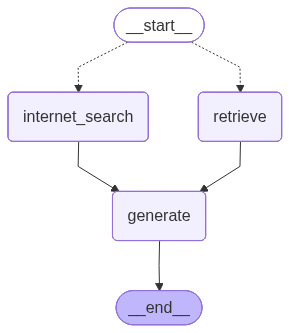

In [25]:
from IPython.display import display, Image
try:
  display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [26]:
inputs = {
    "question": "kapan jadwal UTBK 2026"
}

for output in app.stream(inputs):
    for key, value in output.items():
        print(f"Node {key} finished.")

---ROUTE QUESTION---
kapan jadwal UTBK 2026
---ROUTE QUESTION TO INTERNET SEARCH---
---internet search---
kapan jadwal UTBK 2026
Node internet_search finished.
---GENERATING ANSWER---
Halo! Terima kasih sudah bertanya tentang jadwal UTBK 2026. Berdasarkan informasi yang tersedia, jadwal UTBK 2026 adalah sebagai berikut:
* Pendaftaran SNBP: 3-18 Februari
* UTBK: 25 Maret-7 April
* Hasil SNBP diumumkan: 31 Maret
* Hasil SNBT diumumkan: 25 Mei 2026

Perlu diingat bahwa penyelenggaraan UTBK pada hari Jumat hanya dilaksanakan 1 sesi. Jika Anda memerlukan informasi lebih lanjut atau memiliki pertanyaan lain, jangan ragu untuk bertanya.

Apakah ada hal lain yang bisa saya bantu?
Node generate finished.


In [29]:
inputs = {
    "question": "Apa saja program ruangguru"
}

for output in app.stream(inputs):
    for key, value in output.items():
        print(f"Node {key} finished.")

---ROUTE QUESTION---
Apa saja program ruangguru


---ROUTE QUESTION TO RAG---
---RETRIEVER---
Node retrieve finished.
---GENERATING ANSWER---
Halo! Terima kasih sudah bertanya tentang program Ruangguru. Kami memiliki beberapa program yang menarik, antara lain:

* **Ruangpengajar**: Suatu layanan yang merekrut dan memfasilitasi pengembangan kemampuan Mitra Pengajar pada produk ruanglesonline, roboguru, Brain Academy Online, dan ruangles. Melalui ruangpengajar, Mitra Pengajar dapat menambah penghasilan tambahan dengan mengajar di mana saja dan kapan saja!
* **Learning Acceleration Program (LEAP)**: Program internship selama 4 bulan yang dirancang untuk semua mahasiswa dan lulusan baru.
* **Management Associate Program**: Program yang dirancang khusus untuk top talent muda, dengan jalur yangrigor dan akselerasi yang menekankan pada kedalaman dan keluasan dalam pengembangan pribadi.
* **Ruangguru Engineering Academy**: Program yang dirancang untuk mengembangkan kemampuan teknis dan pengembangan diri.

Kami sangat antusias untuk membantu A